# Phase 5 — SHAP Explainability + Retention Levers

Goal: turn the churn model from a black box into a **decision-support tool**. For each flagged subscriber, we explain WHY the model flagged them AND which retention lever the PM should pull.

**Sections:**
- A. Setup — retrain XGBoost (uncalibrated) for SHAP
- B. Compute SHAP values (TreeExplainer)
- C. Global feature importance — which features drive predictions overall?
- D. SHAP summary plot (beeswarm) — direction + magnitude at a glance
- E. Feature dependence for top 3 drivers
- F. Local explanations — three worked examples (high/marginal/low risk)
- G. Feature → intervention mapping
- H. Verdict + handoff to Phase 6

> **Why SHAP over XGBoost's built-in `feature_importances_`?**
> XGBoost's default importance is measured at *training time* by counting split gain — which biases toward high-cardinality features and doesn't tell you the direction of the effect. SHAP measures *prediction-time* contribution per user, is direction-aware (positive = pushes toward churn), and gives you both global patterns AND per-user explanations from the same computation. For a decision-support tool, SHAP is the right tool. Feature importance is a training-time diagnostic.

> **Why the uncalibrated model for SHAP, not the calibrated production model?**
> The calibration wrapper (Platt sigmoid) is a monotonic post-hoc transform. It changes the probability *scale* but not the model's ranking or its feature attributions. Running SHAP on the underlying XGBoost gives us clean log-odds attributions that decompose additively; running it on the calibrated wrapper adds a non-tree layer that TreeExplainer can't decompose properly.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features, train_xgboost
from src.models.explain import (
    compute_shap_values, global_importance, local_explanation,
    map_to_intervention, FEATURE_INTERVENTION_MAP,
)

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup — retrain XGBoost for SHAP

Same three-way split as Phase 4 (same seed) so we're explaining the same test users. Retraining is deterministic and takes < 10 seconds.

In [2]:
raw = load_subscribers('../data/subscribers.csv')
df = build_features(raw)
X, y = prepare_features(df)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42,
)

xgb = train_xgboost(X_train, y_train)
print(f'Retrained XGBoost on train (n={len(X_train):,}) for SHAP analysis')

Retrained XGBoost on train (n=30,000) for SHAP analysis


## B. Compute SHAP values (TreeExplainer)

For tree models, `shap.TreeExplainer` runs **exact SHAP computation via TreeSHAP** — polynomial-time in the depth of the trees. No approximation, no random sampling for the values themselves (we do sample users to keep the beeswarm chart readable, but each user's SHAP is exact).

Values are in **log-odds space**. To turn a SHAP value back into a probability shift, apply the logistic: `Δp ≈ Δlog_odds × p × (1-p)` at the current probability.

In [3]:
SAMPLE_SIZE = 2000
shap_values = compute_shap_values(xgb, X_test, sample_size=SAMPLE_SIZE)
X_shap = X_test.sample(n=SAMPLE_SIZE, random_state=42)
y_shap = y_test.loc[X_shap.index]

print(f'Computed SHAP for {SAMPLE_SIZE} test users')
print(f'Base value (expected log-odds): {shap_values.base_values[0]:.4f}')
print(f'Base value (as probability):    {1/(1+np.exp(-shap_values.base_values[0])):.4f}')

# Sanity check: sum(SHAP) + base_value == raw model output
sample_pred = xgb.predict(X_shap.iloc[[0]], output_margin=True)[0]
sample_check = shap_values.values[0].sum() + shap_values.base_values[0]
print(f'\nSanity check (should match):')
print(f'  raw model margin: {sample_pred:.4f}')
print(f'  sum(shap)+base:   {sample_check:.4f}')

Computed SHAP for 2000 test users
Base value (expected log-odds): -2.9097
Base value (as probability):    0.0517

Sanity check (should match):
  raw model margin: -3.8993
  sum(shap)+base:   -3.8993


> **The sanity check matters.** SHAP's additive-attribution property says: `raw_prediction = sum(all_shap_values) + base_value`. If these don't match, TreeExplainer is set up incorrectly (e.g., wrong model type, wrong feature order). Always run this check on a random sample when using SHAP for the first time on a new model.

## C. Global feature importance (mean |SHAP|)

Rank features by their **average absolute contribution** across users. This tells you which features the model relies on most, without caring about direction.

In [4]:
importance = global_importance(shap_values, list(X_shap.columns), top_n=15)
importance

,feature,mean_abs_shap,mean_signed_shap
0,watch_hours_last_7d,0.275681,-0.081516
1,billing_cycle_annual,0.247276,-0.055661
2,days_since_last_login,0.228046,-0.060274
3,payment_health_score,0.188039,-0.029581
4,tenure_months,0.161667,-0.034980
5,logins_last_30d,0.153866,-0.035615
6,watch_trend_7d_to_30d,0.150383,-0.047375
7,multi_profile,0.098942,-0.010412
8,watch_trend_30d_to_90d,0.097465,-0.025165
9,watch_hours_last_90d,0.089099,-0.041478


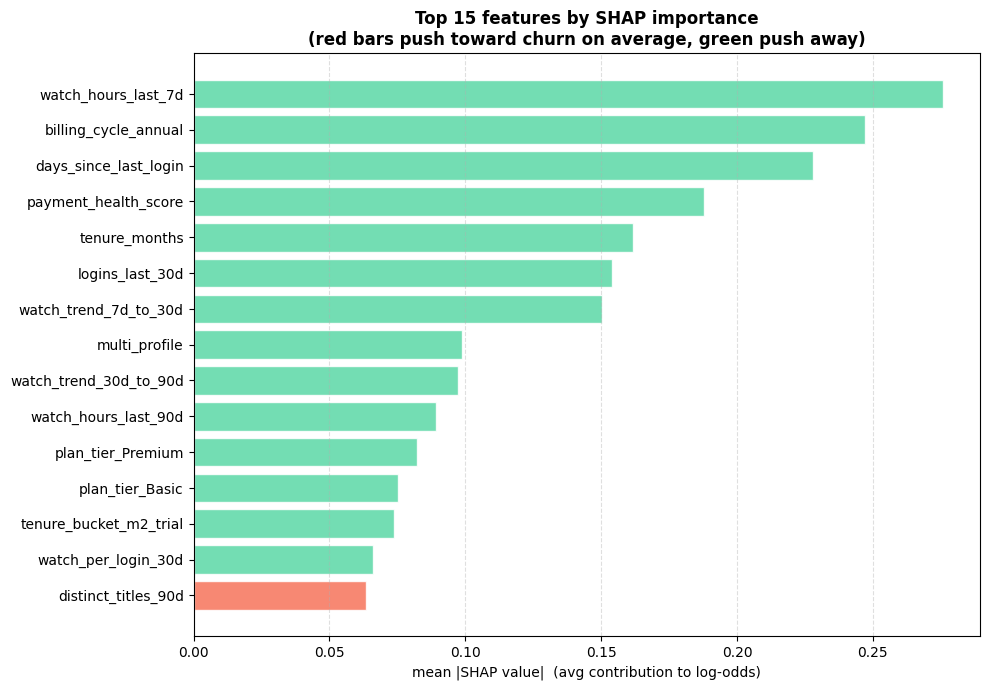

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#F6735B' if v > 0 else '#5AD8A6'
          for v in importance['mean_signed_shap']]
ax.barh(importance['feature'][::-1], importance['mean_abs_shap'][::-1],
        color=colors[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('mean |SHAP value|  (avg contribution to log-odds)')
ax.set_title('Top 15 features by SHAP importance\n'
             '(red bars push toward churn on average, green push away)',
             fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_global_importance.png', dpi=140, bbox_inches='tight')
plt.show()

> **What the color tells you.**
> - **Red bars** = feature pushes toward CHURN on average across users (positive mean signed SHAP)
> - **Green bars** = feature pushes toward RETAIN on average (negative mean signed SHAP)
>
> Some features have big |SHAP| but roughly balance out to zero mean — those affect *different users in different directions*. Beeswarm plot in the next section shows that split.

## D. SHAP summary plot (beeswarm)

The beeswarm is the single most useful SHAP visualization. Each row is a feature; each dot is one user; **x-position = SHAP value** (right = pushes toward churn); **color = feature value** (red = high, blue = low).

**Reading it:**
- A row that's mostly red on the right, blue on the left = "high values of this feature increase churn risk"
- A row with red on the left, blue on the right = "high values of this feature DECREASE churn risk"
- A wide spread = feature has variable importance across users (context-dependent)

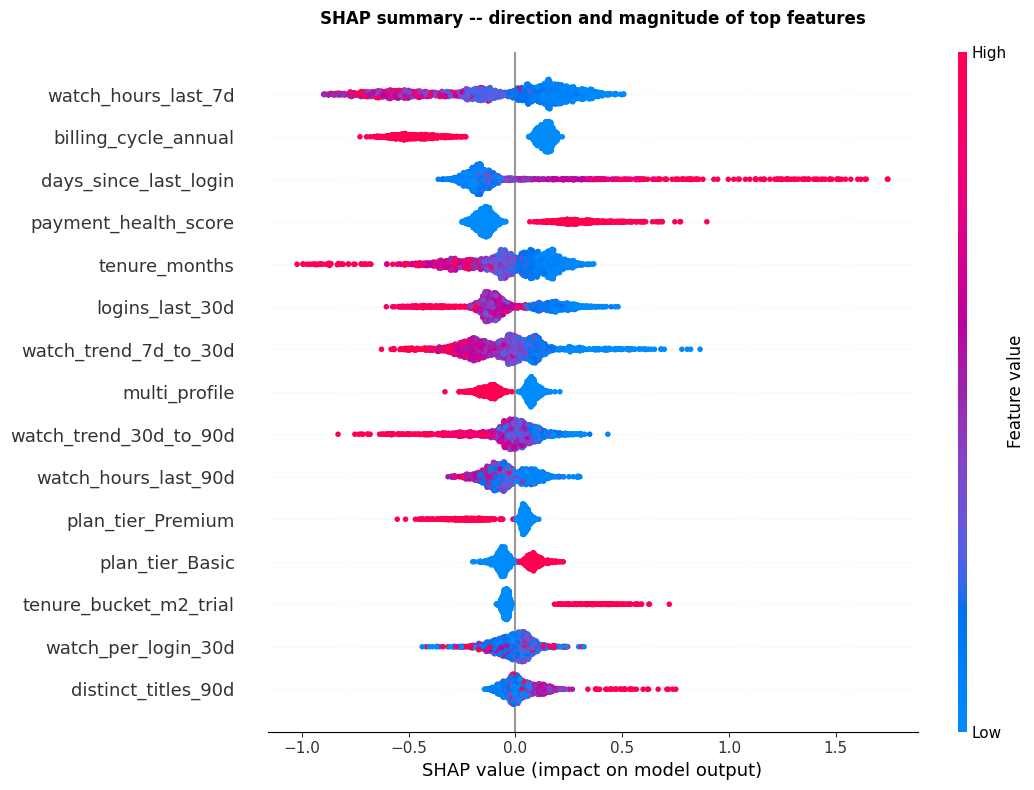

In [6]:
plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False, plot_size=None)
plt.title('SHAP summary -- direction and magnitude of top features',
          fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_beeswarm.png', dpi=140, bbox_inches='tight')
plt.show()

> **Pattern to watch for in the beeswarm:** features where the color-vs-position relationship is unclear (blue and red intermixed) are context-dependent — their effect depends on interactions with other features. Tree models capture that; linear models miss it entirely. When top SHAP features all show clean color separation, the linear baseline is likely competitive (which matches what we saw in Phase 4).

## E. Feature dependence — top 3 drivers

Dependence plot: for one feature, scatter `feature value` (x) vs `SHAP value` (y). Shows the **shape** of the feature's effect — linear, threshold, saturating, or non-monotonic.

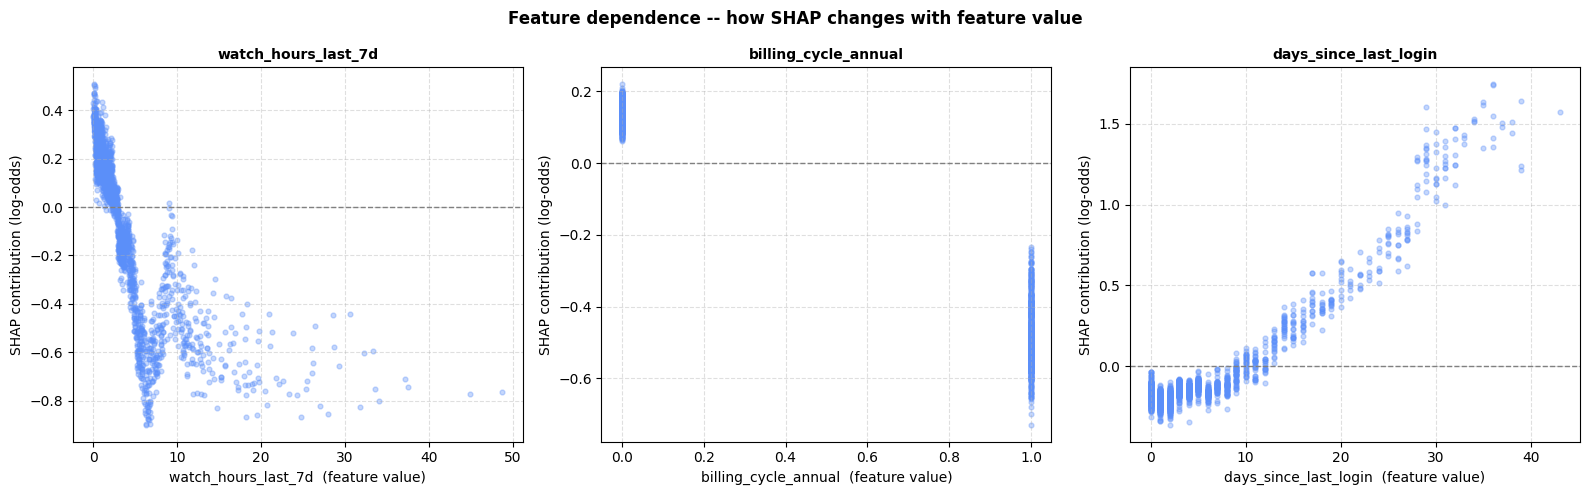

Top 3 drivers: ['watch_hours_last_7d', 'billing_cycle_annual', 'days_since_last_login']


In [7]:
top_3 = importance['feature'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, top_3):
    idx = list(X_shap.columns).index(feat)
    x = X_shap.iloc[:, idx].values
    s = shap_values.values[:, idx]
    ax.scatter(x, s, alpha=0.35, s=12, color='#5B8FF9')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(f'{feat}  (feature value)')
    ax.set_ylabel('SHAP contribution (log-odds)')
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Feature dependence -- how SHAP changes with feature value',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_shap_dependence.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'Top 3 drivers: {top_3}')

> **What dependence plots tell you the beeswarm doesn't.**
> The beeswarm shows *how much* each feature matters, in aggregate. Dependence shows *at what feature values* the effect turns on or plateaus. Example: if `days_since_last_login` has SHAP flat at zero for values 0-7, then rises steeply for values > 14, that's a **threshold effect** — the PM can use "14 days inactive" as an interpretable trigger, not a black-box score.

## F. Local explanations — three worked examples

Pick three users at different risk levels and explain each prediction. This is where SHAP earns its keep for stakeholders — every flagged user comes with a *why* the CS team can read.

In [8]:
pred_proba = xgb.predict_proba(X_shap)[:, 1]

example_indices = [
    ('HIGH RISK', int(np.argmax(pred_proba))),
    ('MARGINAL',  int(np.argmin(np.abs(pred_proba - 0.15)))),
    ('LOW RISK',  int(np.argmin(pred_proba))),
]

for label, idx in example_indices:
    p = pred_proba[idx]
    actual = int(y_shap.iloc[idx])
    print(f'\n{"="*70}')
    print(f'[{label}]  P(churn)={p:.3f}  actual={actual}')
    print(f'{"="*70}')
    local = local_explanation(shap_values, X_shap, list(X_shap.columns),
                              idx=idx, top_n=6)
    print(local.to_string(index=False))

    top_risk = local[local['direction'] == 'RISK+'].head(1)
    if not top_risk.empty:
        feat = top_risk['feature'].iloc[0]
        lever = map_to_intervention(feat)
        print(f'\nTop intervention lever: {lever["lever"]}  (cost=${lever["cost"]:.0f})')
        print(f'Reason: {lever["note"]}')


[HIGH RISK]  P(churn)=0.569  actual=0
              feature  feature_value  shap_value direction
days_since_last_login      32.000000    1.307050     RISK+
watch_trend_7d_to_30d       0.568272    0.591709     RISK+
      logins_last_30d       2.000000    0.326750     RISK+
 payment_health_score       1.000000    0.274103     RISK+
 watch_hours_last_90d      80.300000   -0.163959     RISK-
  watch_per_login_30d       9.050000   -0.156636     RISK-

Top intervention lever: Re-engagement email sequence  (cost=$1)
Reason: Inactive users need a reason to come back

[MARGINAL]  P(churn)=0.150  actual=0
               feature  feature_value  shap_value direction
 days_since_last_login      30.000000    1.048047     RISK+
tenure_bucket_m2_trial       1.000000    0.589098     RISK+
   watch_hours_last_7d       6.600000   -0.544307     RISK-
 watch_trend_7d_to_30d       1.188475   -0.359433     RISK-
       logins_last_30d       3.000000    0.231221     RISK+
    distinct_titles_7d       7.0000

> **The narrative pattern:** "This user is flagged at X% risk because of A, B, and C. Recommended action: intervention D (\$Y cost, expected uplift E)." That's what Phase 6's decision rule turns into an ROI number. Without SHAP you can only say "the model flagged this user"; with SHAP you can say WHY and pair it with the right lever.

## G. Feature → intervention mapping

The bridge between the model and the decision rule. Each top feature is paired with a concrete retention lever the PM can execute. Curated with the Retention PM (Marcus Lee) so it's not us guessing at business logic.

In [9]:
lever_rows = []
for feat, spec in FEATURE_INTERVENTION_MAP.items():
    lever_rows.append({
        'feature': feat,
        'lever': spec['lever'],
        'cost': f'${spec["cost"]:.0f}',
        'note': spec['note'],
    })
lever_df = pd.DataFrame(lever_rows)
lever_df

,feature,lever,cost,note
0,watch_trend_7d_to_30d,Personalized content push,$1,Declining engagement -> curated playlist push ...
1,watch_trend_30d_to_90d,Personalized content push,$1,Slow-burn disengagement -> re-engagement email...
2,days_since_last_login,Re-engagement email sequence,$1,Inactive users need a reason to come back
3,logins_last_30d,Re-engagement email sequence,$1,Low login frequency -> weekly recap emails
4,support_tickets_7d,White-glove support callback,$5,Recent ticket escalation -> proactive support ...
5,tickets_recency_ratio,White-glove support callback,$5,Sudden burst of tickets = frustration; catch b...
6,payment_failures_30d,Payment method update prompt + $5 credit,$5,Failed payments often not a churn decision -- ...
7,payment_failures_recency_ratio,Payment method update prompt + $5 credit,$5,Recent failures spike -> emergency retry + car...
8,payment_health_score,Payment method update prompt + $5 credit,$5,Composite payment risk score
9,days_until_promo_expires,Extend promo or offer tier upgrade,$5,Users on the cusp of losing discounts -- preve...


> **What's actionable and what isn't.**
> - **Actionable:** engagement decline, ticket escalation, payment failures, promo expiry, plan changes, trial-drop cohort — these have levers the team can pull
> - **Diagnostic only:** tenure, auto_renew status, plan_tier — these tell the model who's at risk but the team can't intervene on them directly
>
> The Phase 6 decision rule uses *only* actionable features when choosing an intervention. Diagnostic features still contribute to the risk score, but they don't drive intervention choice.

## H. Phase 5 verdict + Phase 6 handoff

**What Phase 5 delivers to Phase 6:**

1. **Per-user P(churn)** from the calibrated XGBoost (Phase 4 model)
2. **Per-user top SHAP driver** — the strongest actionable feature
3. **Intervention cost + expected uplift** from the lever mapping above
4. **LTV by plan tier** from the scenario brief

**The Phase 6 decision rule:**

```
best_lever(user) = argmax over levers of:
    P(churn | user)  ×  uplift(lever)  ×  LTV(user_tier)
    minus
    cost(lever)
```

Where:
- `P(churn)` comes from the calibrated model
- `uplift(lever)` is the expected reduction in churn probability from that intervention (curated with the PM)
- `LTV(user_tier)` is the customer lifetime value if retained
- `cost(lever)` is the intervention cost

**Handoff to Phase 6.**

In [10]:
top_5 = importance.head(5)['feature'].tolist()
print('Top 5 SHAP drivers -- Phase 6 will build the decision rule around these:')
for feat in top_5:
    lever = map_to_intervention(feat)
    actionable = '[ACTIONABLE]' if lever['cost'] > 0 else '[diagnostic]'
    print(f'  {actionable} {feat:<35}  lever: {lever["lever"]}')

n_actionable = sum(1 for f in importance['feature']
                   if map_to_intervention(f)['cost'] > 0)
print(f'\nOf top 15 features, {n_actionable} have an actionable intervention lever.')
print('\nReady for Phase 6 (cost-aware decision rule + ROI sweep).')

Top 5 SHAP drivers -- Phase 6 will build the decision rule around these:
  [diagnostic] watch_hours_last_7d                  lever: N/A (diagnostic feature)
  [ACTIONABLE] billing_cycle_annual                 lever: Upgrade-to-annual offer
  [ACTIONABLE] days_since_last_login                lever: Re-engagement email sequence
  [ACTIONABLE] payment_health_score                 lever: Payment method update prompt + $5 credit
  [diagnostic] tenure_months                        lever: N/A -- structural signal

Of top 15 features, 6 have an actionable intervention lever.

Ready for Phase 6 (cost-aware decision rule + ROI sweep).
